# Importation des packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle 
import scipy.stats as st

# Définition des fonctions

### Fonction pour agréger une métrique

In [2]:
def collect_metrics_all_folds(results, metric_name, class_name="Gonade"):
    dice = []
    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            continue
        if isinstance(fold_results, dict):
            dice.extend(fold_results[metric_name][class_name])
        else:
            dice.extend(image_results["metrics"][class_name][metric_name] for image_results in fold_results)
    return dice

def collect_all_folds(results, name):
    categories = []
    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            continue
        if isinstance(fold_results, dict):
            categories.extend(fold_results[name])
        else:
            categories.extend(image_results["metrics"][name] for image_results in fold_results)
    return categories

### Fonction pour visualiser et comparer des boxplots

In [3]:
def plot_boxplot(datasets, labels, colors, size=(6, 4), limite_echelle=np.arange(0, 1.01, 0.05)):
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=size)

    # Si un seul graphique, axes n'est pas une liste
    if n == 1:
        axes = [axes]

    for i, ax in enumerate(axes):

        # Création du boxplot
        boxplot = ax.boxplot(datasets[i], patch_artist=True)

        # Labels
        ax.set_xticks(range(1, len(labels[i]) + 1))
        ax.set_xticklabels(labels[i])

        # Couleurs
        for patch, color in zip(boxplot["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.4)
            patch.set_edgecolor(color)

        # Médianes
        for median in boxplot["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)

        # Grille
        ax.grid(True, linestyle="--", alpha=0.6, axis="y")

        # Échelle
        ax.set_yticks(limite_echelle)
        ax.set_ylim(limite_echelle[0], limite_echelle[-1])

    plt.tight_layout()
    plt.show()


# Visualisation et comparaison des résultats des différents modèles : validation

## Importation des différents modèles

### U-NET models

In [4]:
# ======= CAVITE =======
# U-Net 2 classes
with open('../UNet/saves/Global/results_UNet_2classes.pkl', 'rb') as f:
    results_UNET_2classes = pickle.load(f)

# AttentionUNet++ 2 classes
with open('../UNet/saves/Global/results_AttentionUNet++_2classes.pkl', 'rb') as f:
    results_AttentionUNet_2classes = pickle.load(f)

# CSA-Net 2 classes
with open('../UNet/saves/Global/results_CSANet_3classes.pkl', 'rb') as f:
    results_CSANet_2classes = pickle.load(f)


# ======= OEUFS =======
# U-Net oeufs
with open('../UNet/saves/Global/results_UNet_oeufs.pkl', 'rb') as f:
    results_UNET_oeufs= pickle.load(f)

# U-Net oeufs
with open('../UNet/saves/Global/results_UNet_oeufs_contour.pkl', 'rb') as f:
    results_UNET_oeufs_contour= pickle.load(f)

# EggSegUNet
with open('../UNet/saves/Global/results_EggSegmentationHVUNet_oeufs.pkl', 'rb') as f:
    results_SegHV_oeufs = pickle.load(f)

### YOLO models

In [5]:
# YOLO oeufs
with open('../YOLO26/saves/results_YOLO_instance_oeufs.pkl', 'rb') as fp:
    results_YOLO_instance_oeufs = pickle.load(fp)

# YOLO oeufs
with open('../YOLO26/saves/results_YOLO_instance_oeufsclasses.pkl', 'rb') as fp:
    results_YOLO_instance_oeufs2 = pickle.load(fp)

### OpenUS model

In [6]:
with open('../OpenUS-multiclass/OpenUS/output/custom_seg_cv5_2classes/results_OpenUS_2classes.pkl', 'rb') as fp:
    results_OpenUS_2classes = pickle.load(fp)

### Moyenne et écart type des Dice par fold

In [9]:
def metrique_moyennes_par_fold(results, classe="Gonade", metric_name="dice_by_class"):
    moyennes = {}
    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            continue
        if isinstance(fold_results, dict):
            valeurs = fold_results[metric_name][classe]
        else:
            valeurs = [image["metrics"][classe][metric_name] for image in fold_results]
        moyennes[fold_name] = np.nanmean(np.asarray(valeurs, dtype=float))
    return moyennes

modeles_dice = {
    "U-Net 2 classes": (results_UNET_2classes, "Gonade", "dice_by_class"),
    "Attention U-Net++ 2 classes": (results_AttentionUNet_2classes, "Gonade", "dice_by_class"),
    "CSA-Net 2 classes": (results_CSANet_2classes, "Gonade", "dice_by_class"),
    "OpenUS 2 classes": (results_OpenUS_2classes, "Gonade", "dice_by_class"),
    "U-Net œufs": (results_UNET_oeufs, "Oeuf", "dice_by_class"),
    "EggSegUNet": (results_SegHV_oeufs, "Oeuf", "dice_by_class"),
    "YOLO instance œufs": (results_YOLO_instance_oeufs, "Oeuf", "dice"),
    "YOLO instance œufs classes": (results_YOLO_instance_oeufs2, "Oeuf", "dice"),
}

for nom, (results, classe, metric_name) in modeles_dice.items():
    dice_folds = metrique_moyennes_par_fold(results, classe, metric_name)
    valeurs = np.asarray(list(dice_folds.values()), dtype=float)
    print(f"{nom} — Dice : moyenne = {np.mean(valeurs):.3f}, écart type = {np.std(valeurs):.3f}")
    print("  Dice moyen par fold :", {fold: round(valeur, 3) for fold, valeur in dice_folds.items()})

modeles_iou = {nom: (results, classe, "iou_by_class" if metric_name == "dice_by_class" else "iou")
               for nom, (results, classe, metric_name) in modeles_dice.items()}

for nom, (results, classe, metric_name) in modeles_iou.items():
    iou_folds = metrique_moyennes_par_fold(results, classe, metric_name)
    valeurs = np.asarray(list(iou_folds.values()), dtype=float)
    print(f"{nom} — IoU : moyenne = {np.mean(valeurs):.3f}, écart type = {np.std(valeurs):.3f}")
    print("  IoU moyen par fold :", {fold: round(valeur, 3) for fold, valeur in iou_folds.items()})

modeles_diff_surface = {
    "U-Net 2 classes": (results_UNET_2classes, "Gonade", "diff_surface"),
    "Attention U-Net++ 2 classes": (results_AttentionUNet_2classes, "Gonade", "diff_surface"),
    "CSA-Net 2 classes": (results_CSANet_2classes, "Gonade", "diff_surface"),
    "OpenUS 2 classes": (results_OpenUS_2classes, "Gonade", "diff_surface"),
    "U-Net œufs": (results_UNET_oeufs, "Oeuf", "diff_surface"),
    "U-Net œufs contour": (results_UNET_oeufs_contour, "Oeuf", "diff_surf"),
    "EggSegUNet": (results_SegHV_oeufs, "Oeuf", "diff_surface"),
    "YOLO instance œufs": (results_YOLO_instance_oeufs, "Oeuf", "diff_surface"),
}

for nom, (results, classe, metric_name) in modeles_diff_surface.items():
    diff_folds = metrique_moyennes_par_fold(results, classe, metric_name)
    valeurs = np.asarray(list(diff_folds.values()), dtype=float)
    print(f"{nom} — Différence de surface : moyenne = {np.nanmean(valeurs):.3f}, écart type = {np.nanstd(valeurs):.3f}")
    print("  Différence de surface moyenne par fold :", {fold: round(valeur, 3) for fold, valeur in diff_folds.items()})

U-Net 2 classes — Dice : moyenne = 0.765, écart type = 0.047
  Dice moyen par fold : {'fold_1': np.float64(0.732), 'fold_2': np.float64(0.786), 'fold_3': np.float64(0.72), 'fold_4': np.float64(0.739), 'fold_5': np.float64(0.849)}
Attention U-Net++ 2 classes — Dice : moyenne = 0.767, écart type = 0.054
  Dice moyen par fold : {'fold_1': np.float64(0.706), 'fold_2': np.float64(0.786), 'fold_3': np.float64(0.733), 'fold_4': np.float64(0.749), 'fold_5': np.float64(0.861)}
CSA-Net 2 classes — Dice : moyenne = 0.706, écart type = 0.062
  Dice moyen par fold : {'fold_1': np.float64(0.634), 'fold_2': np.float64(0.765), 'fold_3': np.float64(0.653), 'fold_4': np.float64(0.685), 'fold_5': np.float64(0.791)}
OpenUS 2 classes — Dice : moyenne = 0.772, écart type = 0.027
  Dice moyen par fold : {'fold_1': np.float64(0.768), 'fold_2': np.float64(0.739), 'fold_3': np.float64(0.746), 'fold_4': np.float64(0.806), 'fold_5': np.float64(0.801)}
U-Net œufs — Dice : moyenne = 0.363, écart type = 0.052
  Dice

## Comparaisons globales des modèles

In [10]:
names_gonade = collect_all_folds(results_UNET_2classes, "name")
names_oeufs = collect_all_folds(results_UNET_oeufs, "name")
names_gonade_OpenUS = collect_all_folds(results_OpenUS_2classes, "name")

### Récupération des temps d'entrainement moyens - des IOU - Diff surfaces

In [ ]:
# -------- Temps d'exécution des modèles --------
print("\n-------------- Time --------------\n")
print(f"UNet 2 classes: {np.sum([results_UNET_2classes[fold]["time"] for fold in results_UNET_2classes])/60:.2f} minutes")
print(f"Attention UNet++ 2 classes: {np.sum([results_AttentionUNet_2classes[fold]["time"] for fold in results_AttentionUNet_2classes])/60:.2f} minutes")
print(f"CSA-Net 2 classes: {np.sum([results_CSANet_2classes[fold]["time"] for fold in results_CSANet_2classes])/60:.2f} minutes")

# -------- IOU --------
print("\n-------------- IoU --------------\n")
print(f"IoU moyen U-NEt 2 classes : {np.mean(collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f} (std : {np.std(collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f})")
print(f"IoU moyen Attention U-NEt 2 classes : {np.mean(collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f} (std : {np.std(collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f})")
print(f"IoU moyen CSA-Net 2 classes : {np.mean(collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f} (std : {np.std(collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f})")  
print(f"IoU moyen OpenUS 2 classes : {np.mean(collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f} (std : {np.std(collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f})")

# -------- Diff surface --------
print("\n-------------- Différence de surface (en cm2) --------------\n")
print(f"Diff surface moyen U-NEt 2 classes : {np.nanmean(collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="diff_surface")):.3f})")
print(f"Diff surface moyen Attention U-NEt 2 classes : {np.nanmean(collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="diff_surface")):.3f})")
print(f"Diff surface moyen CSA-Net 2 classes : {np.nanmean(collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="diff_surface")):.3f})")
print(f"Diff surface moyen OpenUS 2 classes : {np.nanmean(collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="diff_surface")):.3f})")


-------------- Time --------------

UNet 2 classes: 22.15 minutes
Attention UNet++ 2 classes: 16.39 minutes
CSA-Net 2 classes: 54.19 minutes


TypeError: list indices must be integers or slices, not str

### Récupération des Dice

In [13]:
# Cavite
DICE_UNET_2classes_Gonade = collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="dice_by_class")
DICE_ATTENTION_UNET_2classes_Gonade = collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="dice_by_class")
DICE_CSANet_2classes_Gonade = collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="dice_by_class")
DICE_OpenUS_2classes_Gonade = collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="dice_by_class")

# Oeufs
DICE_UNET_oeufs = collect_metrics_all_folds(results_UNET_oeufs, class_name="Oeuf", metric_name="dice_by_class")
DICE_UNET_oeufs_contour = collect_metrics_all_folds(results_UNET_oeufs_contour, class_name="Oeuf", metric_name="dice_by_class")
DICE_SegHV_oeufs = collect_metrics_all_folds(results_SegHV_oeufs, class_name="Oeuf", metric_name="dice_by_class")
DICE_YOLO_instance_oeufs = collect_metrics_all_folds(results_YOLO_instance_oeufs, class_name="Oeuf", metric_name="dice")
DICE_YOLO_instance_oeufs2 = collect_metrics_all_folds(results_YOLO_instance_oeufs2, class_name="Oeuf", metric_name="dice")

### Récupération de la différence de surface

In [14]:
# Cavite
Diff_UNET_2classes = collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="diff_surface")
Diff_ATTENTION_UNET_2classes = collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="diff_surface")
Diff_CSANet_2classes = collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="diff_surface")
Diff_OpenUS_2classes = collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="diff_surface")

# oeufs
Diff_UNET_oeufs = collect_metrics_all_folds(results_UNET_oeufs, class_name="Oeuf", metric_name="diff_surface")
Diff_UNET_oeufs_contour = collect_metrics_all_folds(results_UNET_oeufs_contour, class_name="Oeuf", metric_name="diff_surf")
Diff_SegHV_oeufs = collect_metrics_all_folds(results_SegHV_oeufs, class_name="Oeuf", metric_name="diff_surface")
Diff_YOLO_instance_oeufs = collect_metrics_all_folds(results_YOLO_instance_oeufs, class_name="Oeuf", metric_name="diff_surface")
Diff_YOLO_instance_oeufs2 = collect_metrics_all_folds(results_YOLO_instance_oeufs2, class_name="Oeuf", metric_name="diff_surface")

### Boxplots Dice des gonades

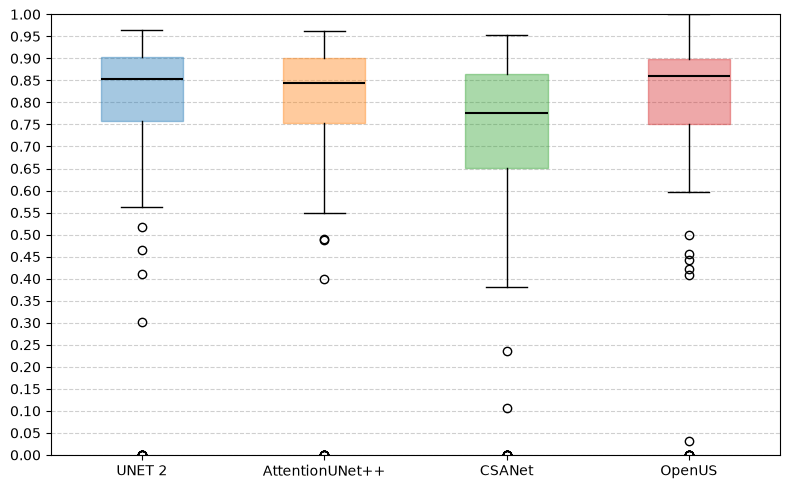

In [15]:
data = [DICE_UNET_2classes_Gonade, DICE_ATTENTION_UNET_2classes_Gonade, DICE_CSANet_2classes_Gonade, DICE_OpenUS_2classes_Gonade]
labels = ["UNET 2", "AttentionUNet++", "CSANet", "OpenUS"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0.00, 1.01, 0.05)
plot_boxplot([data], [labels], colors, size=(8, 5), limite_echelle=limite)

In [13]:
# ------- Comparaison des moyennes ----
print(f"Dice moyen U-NEt 2 classes : {np.mean(DICE_UNET_2classes_Gonade):.3f} (std : {np.std(DICE_UNET_2classes_Gonade):.3f})")
print(f"Dice moyen Attention U-NEt 2 classes : {np.mean(DICE_ATTENTION_UNET_2classes_Gonade):.3f} (std : {np.std(DICE_ATTENTION_UNET_2classes_Gonade):.3f})")
print(f"Dice moyen CSA-Net 2 classes : {np.mean(DICE_CSANet_2classes_Gonade):.3f} (std : {np.std(DICE_CSANet_2classes_Gonade):.3f})")
print(f"Dice moyen OpenUS 2 classes : {np.mean(DICE_OpenUS_2classes_Gonade):.3f} (std : {np.std(DICE_OpenUS_2classes_Gonade):.3f})")

Dice moyen U-NEt 2 classes : 0.766 (std : 0.245)
Dice moyen Attention U-NEt 2 classes : 0.767 (std : 0.235)
Dice moyen CSA-Net 2 classes : 0.706 (std : 0.244)
Dice moyen OpenUS 2 classes : 0.771 (std : 0.236)


In [14]:
# -------------- Analyse outliers --------------------
# Récupère les images avec un DICE entre inf et sup
inf= 0.9
sup = 1.1

# UNET
indices = [i for i,x in enumerate(DICE_UNET_2classes_Gonade) if x < sup and x > inf]
print(f"Dice UNet :{[DICE_UNET_2classes_Gonade[indice] for indice in indices]}")
print(f"Names UNet : {[names_gonade[indice] for indice in indices]}")
print("----------------------------------------------------------------")

# UNET++
indices = [i for i,x in enumerate(DICE_ATTENTION_UNET_2classes_Gonade) if x < sup and x > inf]
print(f"Dice UNet++ :{[DICE_ATTENTION_UNET_2classes_Gonade[indice] for indice in indices]}")
print(f"Names Unet ++ : {[names_gonade[indice] for indice in indices]}")
print("----------------------------------------------------------------")

# CSANET
indices = [i for i,x in enumerate(DICE_CSANet_2classes_Gonade) if x < sup and x > inf]
print(f"Dice CSANet :{[DICE_CSANet_2classes_Gonade[indice] for indice in indices]}")
print(f"Names CSANet : {[names_gonade[indice] for indice in indices]}")
print("----------------------------------------------------------------")

# OPENUS
indices = [i for i,x in enumerate(DICE_OpenUS_2classes_Gonade) if x < sup and x > inf]
print(f"Dice OPENUS :{[DICE_OpenUS_2classes_Gonade[indice] for indice in indices]}")
print(f"Names OPENUS : {[names_gonade_OpenUS[indice] for indice in indices]}")
print("----------------------------------------------------------------")

Dice UNet :[0.9080236554145813, 0.9260372519493103, 0.9190778136253357, 0.9077939987182617, 0.9324748516082764, 0.9531981348991394, 0.9465711116790771, 0.9023623466491699, 0.9061283469200134, 0.9511811137199402, 0.9516494870185852, 0.9503526091575623, 0.9478006958961487, 0.9314644932746887, 0.9274132251739502, 0.9064183831214905, 0.9646077156066895, 0.9374154210090637, 0.9003683924674988, 0.9048002362251282, 0.9223153591156006, 0.9128578901290894, 0.921421229839325, 0.9035928845405579, 0.901357889175415, 0.930915892124176, 0.9145143032073975, 0.917655348777771, 0.9113913774490356, 0.9430245757102966, 0.9276823401451111, 0.9346849918365479, 0.9431267380714417, 0.9400681853294373, 0.9020461440086365, 0.905751645565033, 0.9205169081687927, 0.9116433262825012, 0.9138861894607544, 0.907341718673706]
Names UNet : ['0004672_12.18.23_356948_2019.jpg', '0004673_12.18.32_356948_2019.jpg', '0004674_12.18.40_356948_2019.jpg', '0004675_12.18.49_356948_2019.jpg', '0004862_14.23.23_362702_2020.jpg', 

## Analyse par images

Cette section compare, pour une image donnée, les métriques de segmentation de la gonade obtenues par les différents modèles 3 classes.

In [15]:
import pandas as pd
from pathlib import Path

def extraire_metriques_image(results, nom_image, classe="Gonade"):
    """Extrait les métriques d'une image depuis des résultats U-Net ou YOLO."""
    nom_recherche = Path(nom_image).name

    for fold_results in results.values():
        # Format U-Net : un dictionnaire de listes par fold
        if isinstance(fold_results, dict):
            noms = fold_results.get("name", [])
            for index, nom in enumerate(noms):
                if Path(nom).name == nom_recherche:
                    return {
                        "Dice": fold_results["dice_by_class"][classe][index],
                        "IoU": fold_results["iou_by_class"][classe][index],
                        "Précision": fold_results["precision_by_class"][classe][index],
                        "Rappel": fold_results["recall_by_class"][classe][index],
                        "Différence de surface": (fold_results.get("diff_surface", fold_results.get("diff_surf")))[classe][index],
                    }

        # Format YOLO : une liste de résultats individuels par fold
        else:
            for image_results in fold_results:
                if Path(image_results["image"]).name == nom_recherche:
                    metriques = image_results["metrics"][classe]
                    return {
                        "Dice": metriques["dice"],
                        "IoU": metriques["iou"],
                        "Précision": metriques["precision"],
                        "Rappel": metriques["recall"],
                        "Différence de surface": metriques["diff_surface"],
                    }

    raise ValueError(
        f"L'image '{nom_image}' est introuvable dans les résultats de ce modèle. "
        f"Utilisez le nom d'une image du jeu de validation 2 classes."
    )


def comparer_modeles_pour_image(nom_image, classe="Gonade"):
    modeles = {
        "U-Net": results_UNET_2classes,
        "Attention U-Net++": results_AttentionUNet_2classes,
        "OpenUS": results_OpenUS_2classes,
        "CSA-Net": results_CSANet_2classes,
    }

    lignes = {
        nom_modele: extraire_metriques_image(resultats, nom_image, classe)
        for nom_modele, resultats in modeles.items()
    }

    tableau = pd.DataFrame.from_dict(lignes, orient="index").rename_axis("Modèle").round(3)
    return tableau.sort_values("Dice", ascending=False)

### Sélection de l'image

Modifier la valeur de `nom_image`, puis exécuter la cellule pour afficher la comparaison.

In [18]:
nom_image = "0006263_14.45.50_406915_2022.jpg"
comparer_modeles_pour_image(nom_image)

,Dice,IoU,Précision,Rappel,Différence de surface
Modèle,,,,,
U-Net,0.892,0.805,0.930,0.857,0.065
OpenUS,0.827,0.705,0.853,0.803,0.049
Attention U-Net++,0.738,0.585,0.666,0.828,0.199
CSA-Net,0.644,0.475,0.521,0.844,0.281


### Boxplots Dice des oeufs

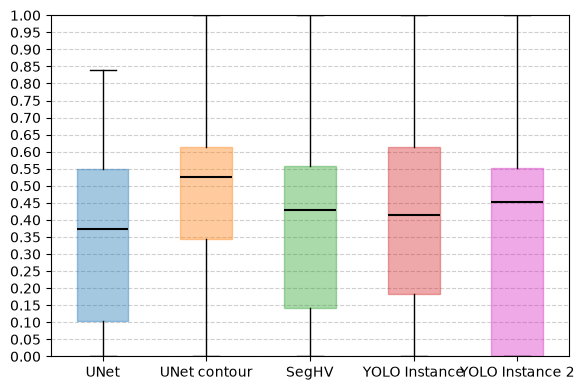

In [17]:
data = [DICE_UNET_oeufs, DICE_UNET_oeufs_contour, DICE_SegHV_oeufs, DICE_YOLO_instance_oeufs, DICE_YOLO_instance_oeufs2]
labels = ["UNet", "UNet contour", "SegHV", "YOLO Instance", "YOLO Instance 2"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0.00, 1.01, 0.05)
plot_boxplot([data], [labels], colors, size=(6, 4), limite_echelle=limite)

In [70]:
# --- Comparaison des moyennes pour les oeufs ---
print(f"Dice moyen U-NEt : {np.mean(DICE_UNET_oeufs):.3f} (std : {np.std(DICE_UNET_oeufs):.3f})")
print(f"Dice moyen U-NEt contour: {np.mean(DICE_UNET_oeufs_contour):.3f} (std : {np.std(DICE_UNET_oeufs_contour):.3f})")
print(f"Dice moyen SegHV : {np.mean(DICE_SegHV_oeufs):.3f} (std : {np.std(DICE_SegHV_oeufs):.3f})")
print(f"Dice moyen YOLO instance : {np.mean(DICE_YOLO_instance_oeufs):.3f} (std : {np.std(DICE_YOLO_instance_oeufs):.3f})")

Dice moyen U-NEt : 0.357 (std : 0.256)
Dice moyen U-NEt contour: 0.465 (std : 0.253)
Dice moyen SegHV : 0.403 (std : 0.255)
Dice moyen YOLO instance : 0.369 (std : 0.249)


### Boxplots Diff surface des gonades

In [1]:
data = [
    Diff_UNET_2classes,
    Diff_ATTENTION_UNET_2classes,
    Diff_CSANet_2classes,
    Diff_OpenUS_2classes
]

data_clean = []

for x in data:
    x = np.array(x, dtype=float)
    x = x[np.isfinite(x)]  # enlève NaN et inf
    data_clean.append(x)

labels = ["U-NET", "AttentionUNet++", "CSANet", "OpenUS"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0, 1.5, 0.1)
plot_boxplot([data_clean], [labels], colors, size=(6, 4), limite_echelle=limite)

NameError: name 'Diff_UNET_2classes' is not defined

### Boxplots Diff surface médiane des oeufs : prédit vs annotation

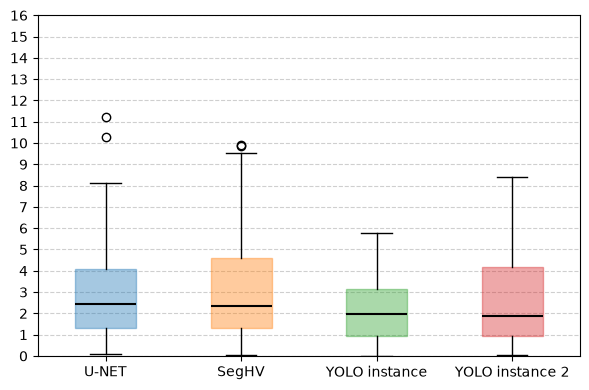

In [ ]:
data = [
    Diff_UNET_oeufs,
    Diff_SegHV_oeufs,
    Diff_YOLO_instance_oeufs,
    Diff_YOLO_instance_oeufs2
]

data_clean = []

for x in data:
    x = np.array(x, dtype=float)
    x = x[np.isfinite(x)]  # enlève NaN et inf
    data_clean.append(x)

labels = ["U-NET",  "SegHV", "YOLO instance", "YOLO instance 2"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0, 17, 1)
plot_boxplot([data_clean], [labels], colors, size=(6, 4), limite_echelle=limite)

## Résultats d'un modèle spécifique

### Sélection du modèle

In [76]:
modele = results_UNET_2classes
Dice_results = DICE_UNET_2classes_Gonade

### Récupération des catégories

In [78]:
categories = collect_all_folds(modele, "category")
positions = collect_all_folds(modele, "ops")
positions_ratio = collect_all_folds(modele, "ops_ratio")
diff_surfaces = collect_all_folds(modele, "diff_surface")

### Boxplots Dice selon les catégories

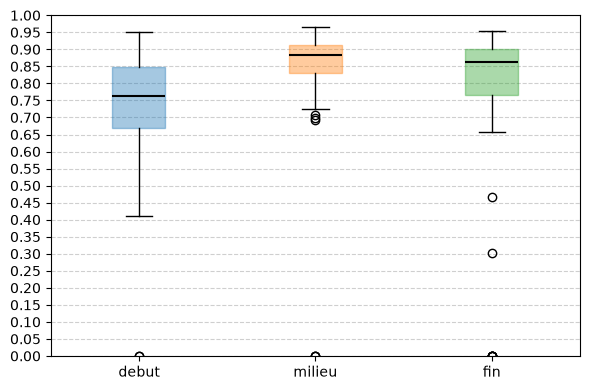

In [79]:
dice_by_category = {}

for category, dice in zip(categories, Dice_results):
    if category not in dice_by_category:
        dice_by_category[category] = []

    dice_by_category[category].append(dice)

labels = list(dice_by_category.keys())
data = [dice_by_category[category] for category in labels]

plot_boxplot(
    datasets=[data],
    labels=[labels],
    size = (6,4),
    colors=["#1f77b4", "#ff7f0e", "#2ca02c" ]
)

In [80]:
# Test de comparaison des moyennes par catégorie
print(st.ttest_ind(data[0], data[2], equal_var=False))

# Test de l'ANOVA
print(st.f_oneway(data[0], data[1], data[2])) #Significatif à 5%

TtestResult(statistic=np.float64(-0.10816923001584985), pvalue=np.float64(0.914142169754535), df=np.float64(77.180083205795))
F_onewayResult(statistic=np.float64(3.0903107382951776), pvalue=np.float64(0.04856039448978857))


### Boxplots Dice selon les positions

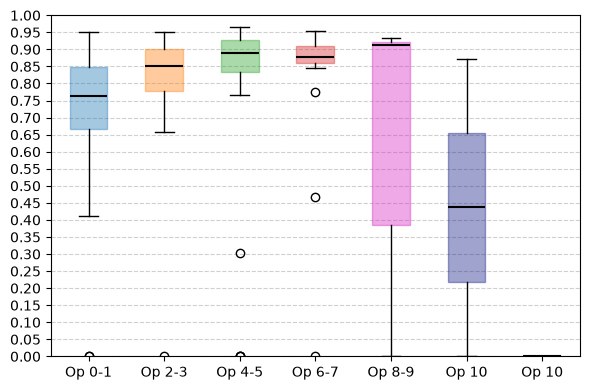

In [81]:
dice_by_position = {}

for position, dice in zip(positions, Dice_results):

    # Regroupement par paires : 0-1, 2-3, 4-5, ...
    group_start = (position // 2) * 2

    if group_start not in dice_by_position:
        dice_by_position[group_start] = []

    dice_by_position[group_start].append(dice)

labels = sorted(dice_by_position.keys())

display_labels = [
    f"Op {position}-{position + 1}" if position < 10 else "Op 10"
    for position in labels
]

data = [dice_by_position[position] for position in labels]

plot_boxplot(
    datasets=[data],
    labels=[display_labels],
    size=(6, 4),
    colors=[
        "#1f77b4", "#ff7f0e", "#2ca02c",
        "#d62728", "#d629c1", "#121b82"
    ]
)

### Boxplots Dice selon les positions ratios

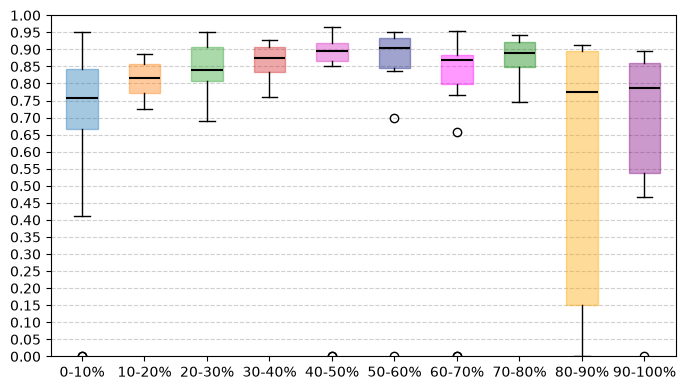

In [82]:
dice_by_position_ratio = {}

for position_ratio, dice in zip(positions_ratio, Dice_results):

    # Regroupement par tranches de 10 %
    group_start = min(int(position_ratio * 10), 9) * 10

    if group_start not in dice_by_position_ratio:
        dice_by_position_ratio[group_start] = []

    dice_by_position_ratio[group_start].append(dice)

labels = sorted(dice_by_position_ratio.keys())

display_labels = [
    f"{position}-{position + 10}%"
    for position in labels
]

data = [dice_by_position_ratio[position] for position in labels]

plot_boxplot(
    datasets=[data],
    labels=[display_labels],
    size=(7, 4),
    colors=[
        "#1f77b4", "#ff7f0e", "#2ca02c",
        "#d62728", "#d629c1", "#121b82",
        "#ff00ff", "green", "orange", "purple"
    ]
)

# Résultats sur l'échantillon de test